# Phase-averaged (decohered) probabilities: `average=True`

A neutrino from an astrophysical source arrives with an oscillation phase
$\Delta m^2 L / 2E$ of order $10^{15}$.  Nothing in that number — the source
distance, the size of the production region, the detector's energy resolution —
is known to anything close to the precision it would take to predict the phase,
so the measurement integrates over many complete cycles and every oscillatory
term averages away.  What survives is

$$P(\nu_\alpha \to \nu_\beta) = \sum_i |V_{\alpha i}|^2 |V_{\beta i}|^2$$

where $V$ diagonalizes the Hamiltonian.  This is the exact $L/E \to \infty$
limit, not an approximation to be refined, and it costs one matrix product
instead of resolving $10^{15}$ radians.

Every oscillation-probability function in Magνs takes `average=True`.  This
notebook shows it for **2ν, 3ν, 4ν and 5ν**, and for a **custom Hamiltonian**
that is not one of the ones Magνs ships with.  Each plot plots the oscillating
probability against baseline (solid) together with its averaged value (dashed),
so the average can be read as what the oscillation settles around.

See the [Phase-Averaged Probabilities](https://mbustama.github.io/Magnus/averaged_probability.html)
page of the documentation for the derivation, the coherence criterion, and the
treatment of position-dependent Hamiltonians.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import magnus.oscprob as oscprob
import magnus.avgprob as avgprob
import magnus.hamiltonians as hamiltonians
import magnus.globaldefs as gd

plt.rcParams['figure.dpi'] = 110

# load_nufit_params returns exactly the six mixing parameters, ready to pass as
# keyword arguments.  OSC_PARAMS_PREDEFINED entries also carry 'name' and
# 'description' strings, which would be forwarded into the propagation machinery
# and rejected there.
osc = gd.load_nufit_params('NuFIT 6.1')
print({k: round(v, 6) for k, v in osc.items()})

{'s12': 0.555698, 's23': 0.685565, 's13': 0.149933, 'dCP': 3.700098, 'D21': 7.5e-05, 'D31': 0.002511}


## Plotting helper

One helper draws every figure below, so the panels stay comparable: the
oscillating probability as a solid line, its averaged value as a dashed line of
the same color, a logarithmic baseline axis, and the same tick and legend
formatting used in the other probability-vs-baseline notebooks.

In [2]:
def prob_label(nu_i, nu_f):
    names = {gd.NUE: r'\nu_e', gd.NUMU: r'\nu_\mu', gd.NUTAU: r'\nu_\tau',
             3: r'\nu_{s_1}', 4: r'\nu_{s_2}'}
    return r'$P_{' + names[nu_i] + r' \to ' + names[nu_f] + r'}$'


def plot_oscillating_and_averaged(distances, prob_curves, prob_averages, labels,
                                  title, filename, ylabel=None, colors=None):
    '''Plots oscillating probabilities against baseline, with their averaged
    values overlaid as dashed lines of the same color.'''
    colors = colors or ['C0', 'C1', 'C2', 'C3', 'C4']

    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18, 9])

    for i, (curve, mean, label) in enumerate(zip(prob_curves, prob_averages, labels)):
        ax.plot(distances/gd.UNIT_KM, curve, lw=1, color=colors[i], ls='-', label=label)
        ax.axhline(mean, lw=1.5, color=colors[i], ls='--')

    # One legend entry explains the line styles, rather than repeating them per curve.
    handles, labs = ax.get_legend_handles_labels()
    handles.append(mpl.lines.Line2D([], [], lw=1.5, color='k', ls='--'))
    labs.append(r'Phase-averaged (\texttt{average=True})' if mpl.rcParams['text.usetex']
                else 'Phase-averaged (average=True)')
    ax.legend(handles, labs, fontsize=17, frameon=True, loc='upper left', handlelength=1.2,
              handleheight=0.7, borderpad=0.8, title_fontsize=20, edgecolor='k',
              labelspacing=0.7, ncol=1, title=r'Channel')

    ax.set_xlabel(r'Baseline, $L$ [km]')
    ax.set_ylabel(ylabel or r'Oscillation probability', labelpad=25)
    ax.set_xscale('log')
    ax.set_xlim(distances[0]/gd.UNIT_KM, distances[-1]/gd.UNIT_KM)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    ax.grid(visible=True, c='0.8', which='both', axis='x')
    ax.grid(visible=True, c='0.8', which='major', axis='y')
    ax.set_title(title, fontsize=20, pad=10)

    plt.tight_layout()
    plt.savefig('../fig/' + filename, dpi=200)
    plt.show()

## Two flavors

The clearest case: a single mass-squared splitting, so the probability is a
plain $\sin^2$ and the averaged value is exactly the mid-line of the
oscillation, $1 - \tfrac{1}{2}\sin^2 2\theta$ for survival.

averaged survival  P_ee = 0.57801
1 - sin^2(2 theta)/2     = 0.57801


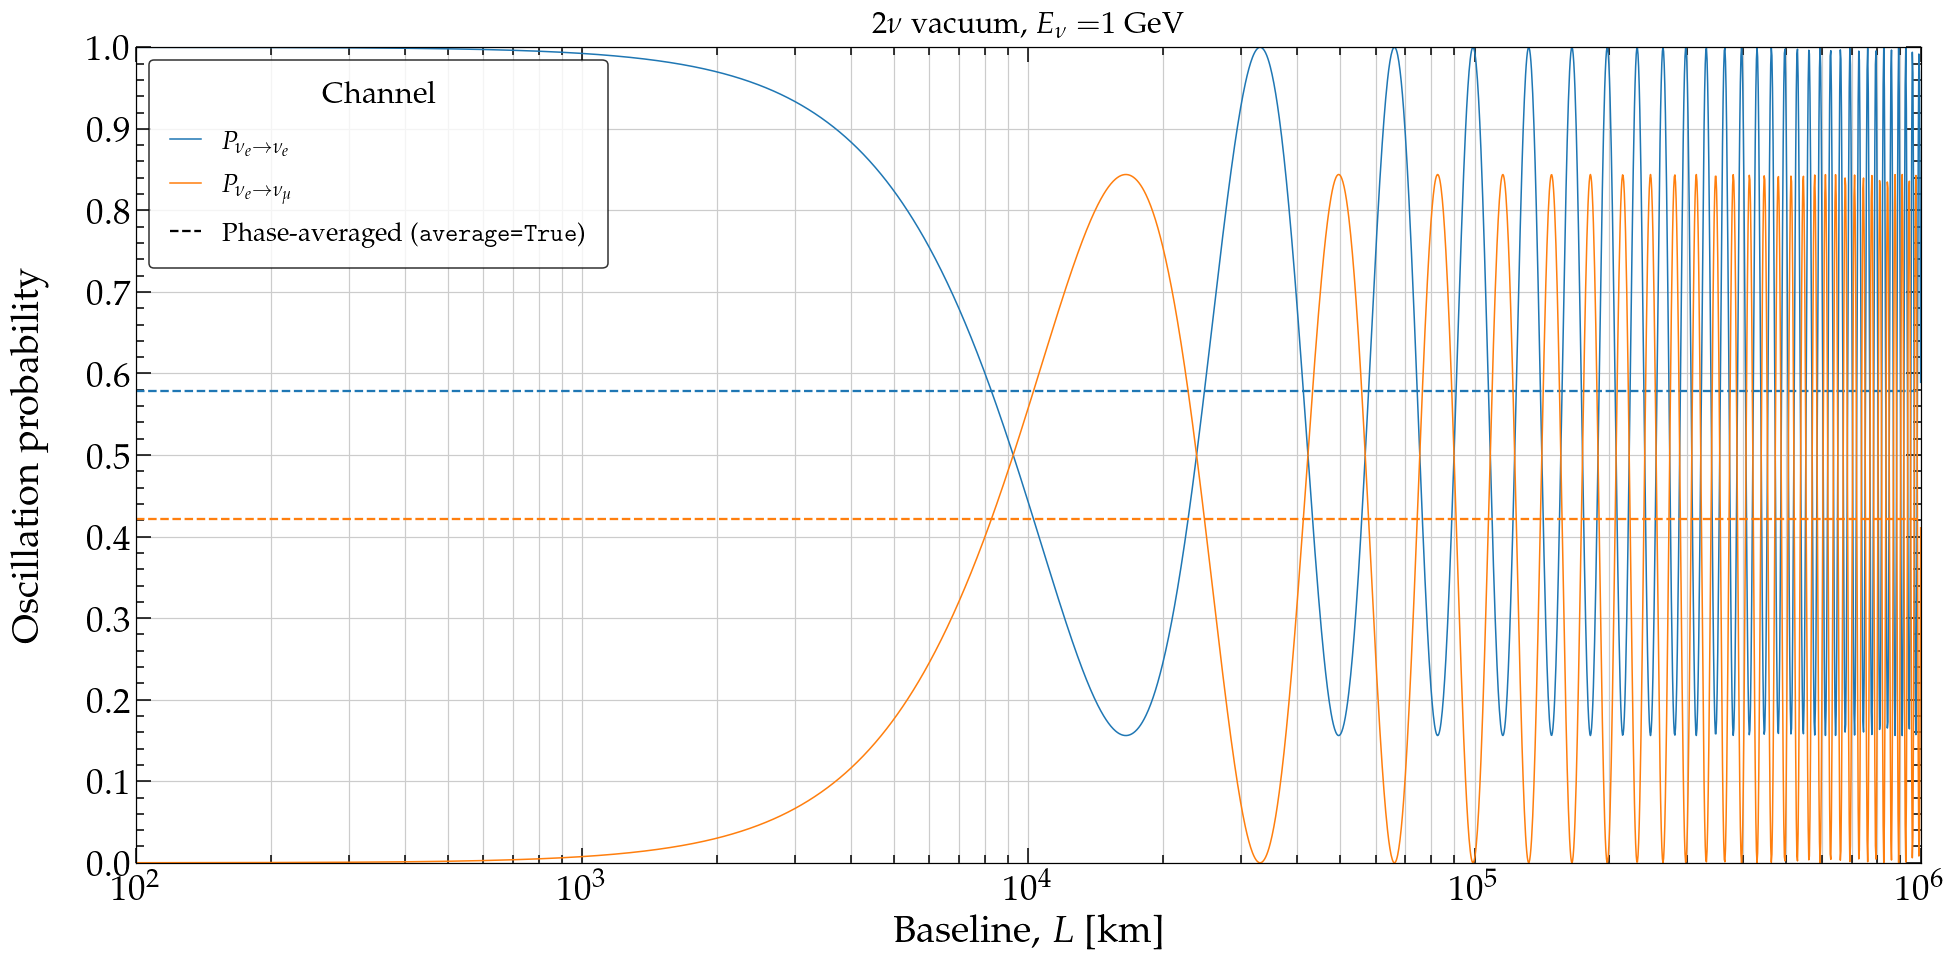

In [3]:
sth, Dm2 = 0.55, 7.5e-5
energy = 1.0*gd.UNIT_GEV
distances = np.logspace(np.log10(1.0e2), np.log10(1.0e6), 3000)*gd.UNIT_KM

# Oscillating: one probability per baseline.
P_osc = np.asarray(oscprob.osc_prob_2nu_vacuum(energy, distances, sth, Dm2))

# Averaged: one number, valid once every pair has decohered.  Taken at the far
# end of the range, where that is true.
P_avg = np.asarray(oscprob.osc_prob_2nu_vacuum(energy, distances[-1], sth, Dm2,
                                               average=True))

print('averaged survival  P_ee =', round(float(P_avg[0, 0]), 5))
print('1 - sin^2(2 theta)/2     =', round(1.0 - 0.5*(2*sth*np.sqrt(1-sth**2))**2, 5))

plot_oscillating_and_averaged(
    distances,
    [P_osc[:, 0, 0], P_osc[:, 0, 1]],
    [P_avg[0, 0], P_avg[0, 1]],
    [prob_label(gd.NUE, gd.NUE), prob_label(gd.NUE, gd.NUMU)],
    r'$2\nu$ vacuum, $E_\nu = ${:.0f} GeV'.format(energy/gd.UNIT_GEV),
    'prob_2nu_vacuum_averaged_vs_baseline.pdf')

## Three flavors

With two splittings there are two oscillation scales, and the averaged value is
no longer the mid-line of anything — it is the incoherent sum over the three
mass eigenstates.  Note the fast $\Delta m^2_{31}$ oscillation riding on the
slow $\Delta m^2_{21}$ one, and that the average is only reached once **both**
have decohered.

averaged 3nu probability matrix:
[[0.5481 0.2155 0.2364]
 [0.2155 0.4071 0.3774]
 [0.2364 0.3774 0.3862]]
rows sum to [1. 1. 1.]


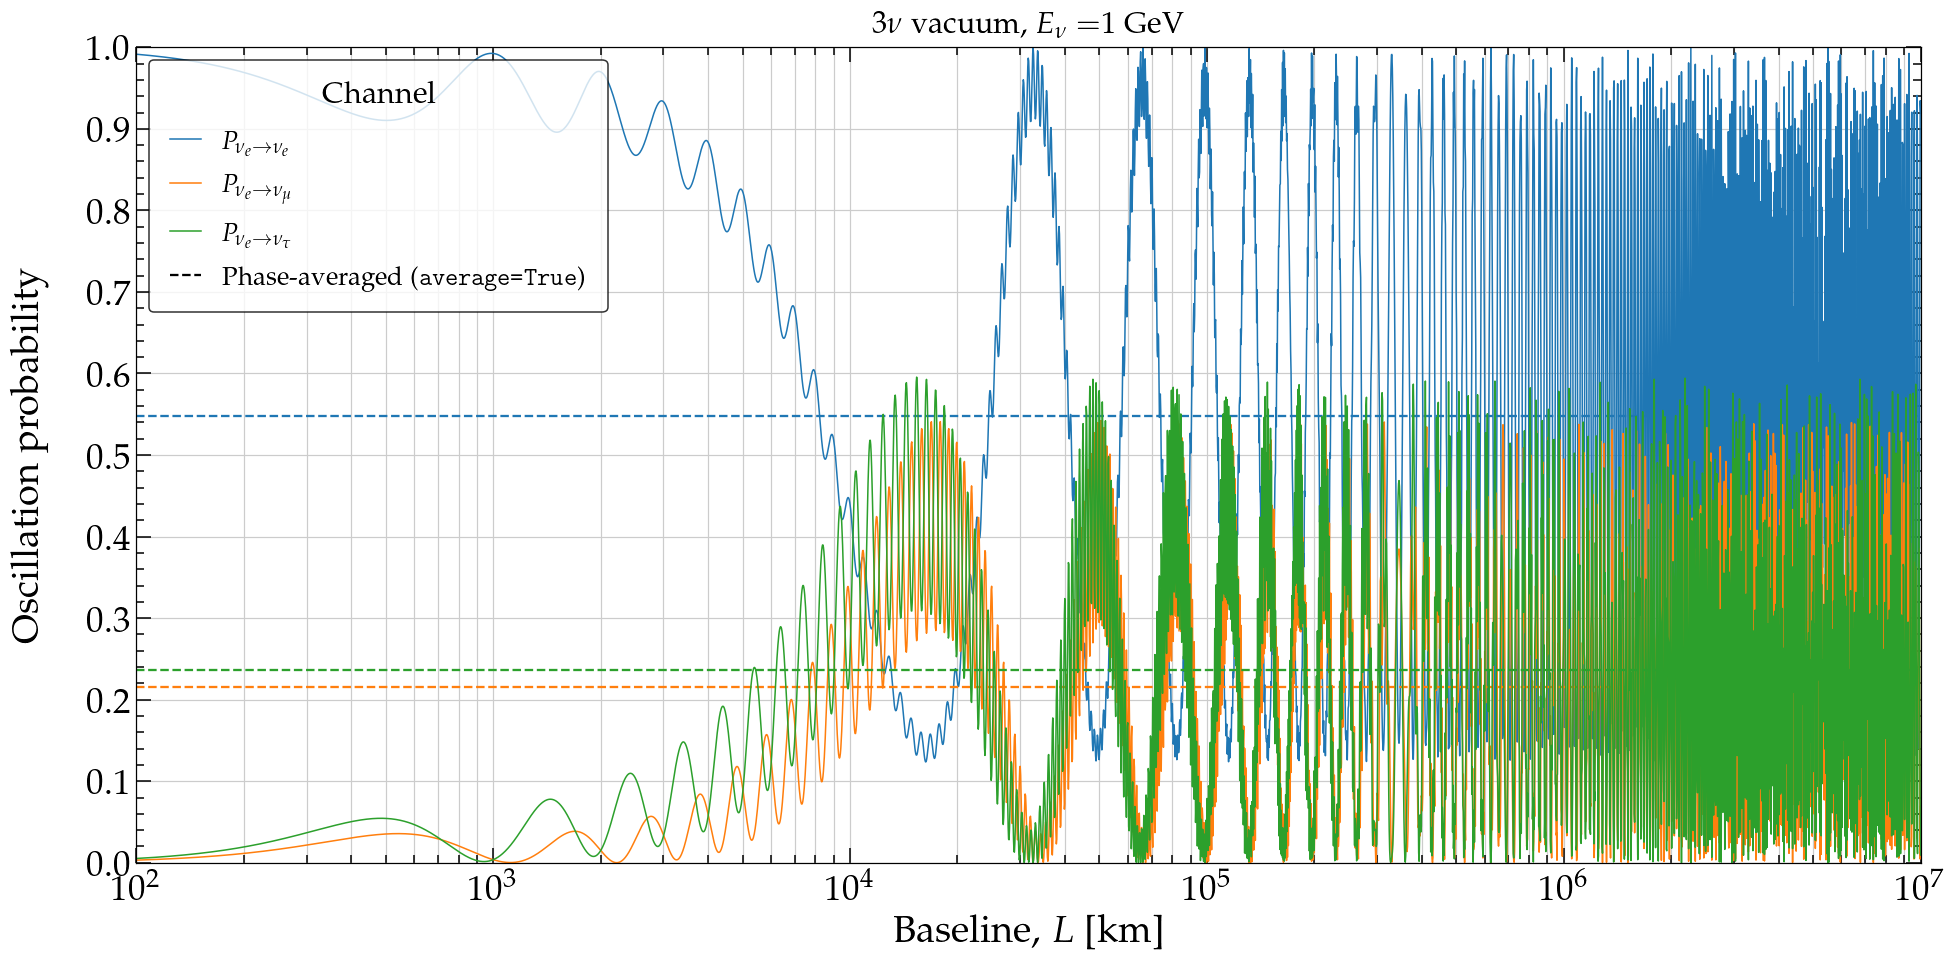

In [4]:
energy = 1.0*gd.UNIT_GEV
distances = np.logspace(np.log10(1.0e2), np.log10(1.0e7), 4000)*gd.UNIT_KM

P_osc = np.asarray(oscprob.osc_prob_3nu_vacuum(energy, distances, **osc))
P_avg = np.asarray(oscprob.osc_prob_3nu_vacuum(energy, distances[-1], average=True, **osc))

print('averaged 3nu probability matrix:')
print(np.round(P_avg, 4))
print('rows sum to', np.round(P_avg.sum(axis=-1), 12))

plot_oscillating_and_averaged(
    distances,
    [P_osc[:, 0, 0], P_osc[:, 0, 1], P_osc[:, 0, 2]],
    [P_avg[0, 0], P_avg[0, 1], P_avg[0, 2]],
    [prob_label(gd.NUE, gd.NUE), prob_label(gd.NUE, gd.NUMU), prob_label(gd.NUE, gd.NUTAU)],
    r'$3\nu$ vacuum, $E_\nu = ${:.0f} GeV'.format(energy/gd.UNIT_GEV),
    'prob_3nu_vacuum_averaged_vs_baseline.pdf')

### The flavor composition of astrophysical neutrinos

The single most quoted consequence: a source producing the pion-decay
composition $(1:2:0)$ delivers something close to equipartition at Earth.  That
is one line once the averaged matrix is in hand.

In [5]:
at_source = np.array([1.0, 2.0, 0.0])/3.0
at_earth = at_source @ P_avg

print('at the source (x1/3):', np.round(at_source*3.0, 3))
print('at Earth      (x1/3):', np.round(at_earth*3.0, 3))
print('flux conserved      :', np.isclose(at_earth.sum(), 1.0))

at the source (x1/3): [1. 2. 0.]
at Earth      (x1/3): [0.979 1.03  0.991]
flux conserved      : True


## Four and five flavors

Nothing about the construction is specific to three flavors: sterile states
simply add rows and columns.  With a large $\Delta m^2_{41}$ the sterile
oscillation is fast and decoheres first, leaving the active sector to average
later.

--- 4nu ---
[[0.5243 0.2112 0.23   0.0346]
 [0.2112 0.3944 0.374  0.0204]
 [0.23   0.374  0.3832 0.0128]
 [0.0346 0.0204 0.0128 0.9322]]


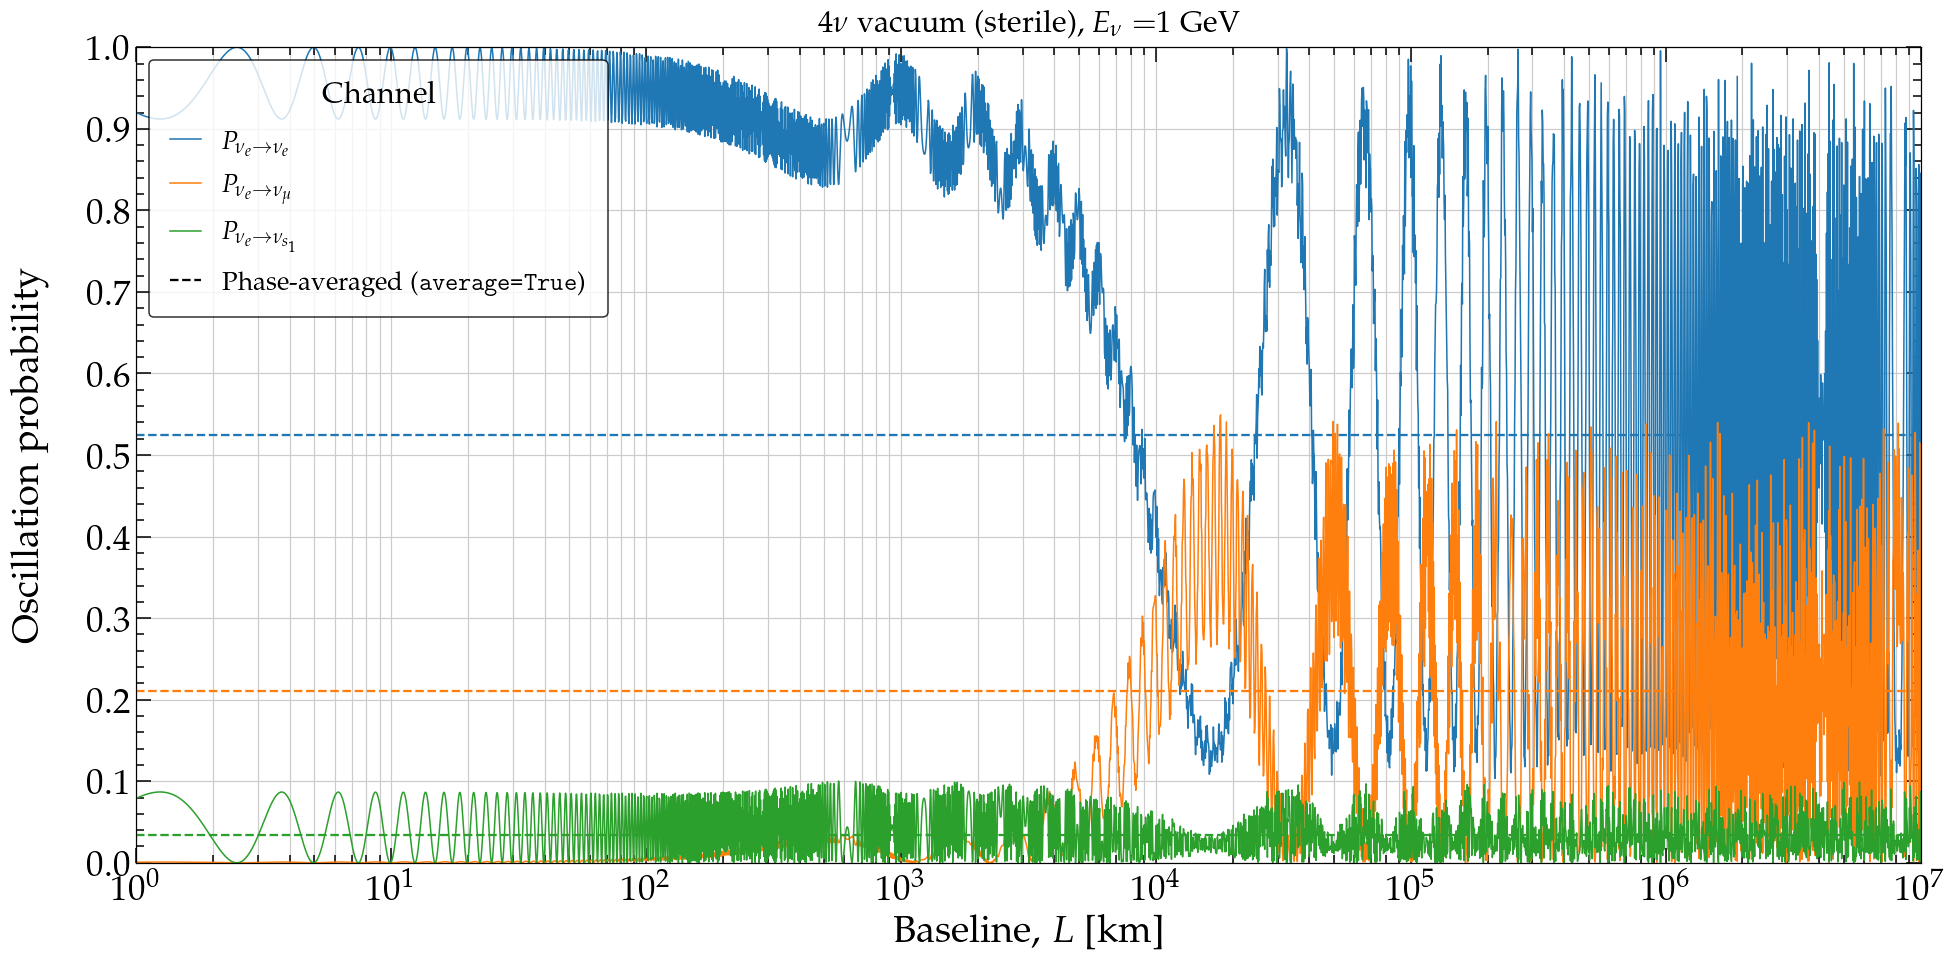

--- 5nu ---
[[5.176e-01 2.100e-01 2.282e-01 3.440e-02 9.900e-03]
 [2.100e-01 3.913e-01 3.732e-01 2.020e-02 5.300e-03]
 [2.282e-01 3.732e-01 3.822e-01 1.270e-02 3.700e-03]
 [3.440e-02 2.020e-02 1.270e-02 9.322e-01 4.000e-04]
 [9.900e-03 5.300e-03 3.700e-03 4.000e-04 9.806e-01]]


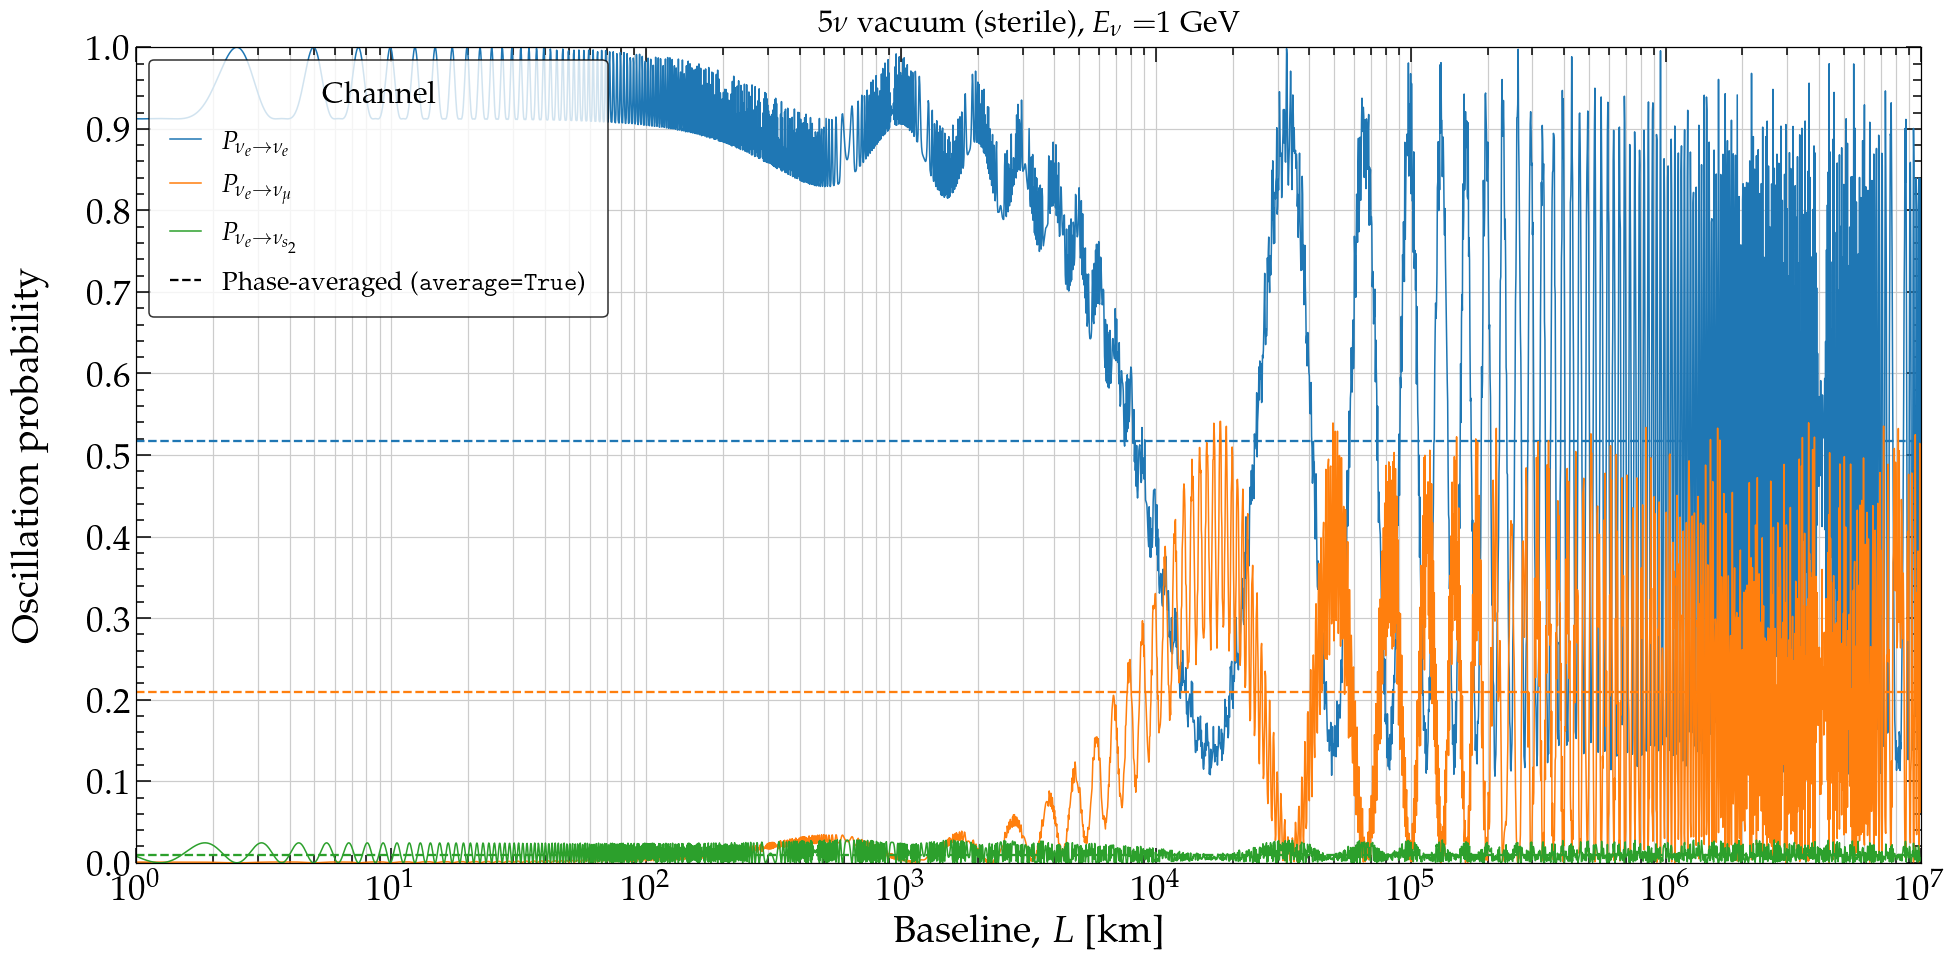

In [6]:
S4 = dict(s14=0.15, d14=0.0, s24=0.10, d24=0.0, s34=0.05, D41=1.0)
S5 = dict(S4, s15=0.08, d15=0.0, s25=0.05, s35=0.03, D51=2.0)

energy = 1.0*gd.UNIT_GEV
distances = np.logspace(np.log10(1.0e0), np.log10(1.0e7), 4000)*gd.UNIT_KM

for num_flavors, sterile, fname in [(4, S4, 'prob_4nu_vacuum_averaged_vs_baseline.pdf'),
                                    (5, S5, 'prob_5nu_vacuum_averaged_vs_baseline.pdf')]:
    fn = getattr(oscprob, f'osc_prob_{num_flavors}nu_vacuum')
    P_osc = np.asarray(fn(energy, distances, **osc, **sterile))
    P_avg = np.asarray(fn(energy, distances[-1], average=True, **osc, **sterile))

    print(f'--- {num_flavors}nu ---')
    print(np.round(P_avg, 4))

    channels = [(gd.NUE, gd.NUE), (gd.NUE, gd.NUMU), (gd.NUE, num_flavors - 1)]
    plot_oscillating_and_averaged(
        distances,
        [P_osc[:, i, f] for i, f in channels],
        [P_avg[i, f] for i, f in channels],
        [prob_label(i, f) for i, f in channels],
        r'${}\nu$ vacuum (sterile), $E_\nu = ${:.0f} GeV'.format(num_flavors,
                                                                 energy/gd.UNIT_GEV),
        fname)

## A custom Hamiltonian

Nothing above depends on the Hamiltonian being one Magνs ships with.  Here is a
hand-built three-level Hamiltonian — a vacuum-like diagonal in a mixing basis of
our own choosing, plus an off-diagonal term with no counterpart in the standard
parameterization — driven through the same two functions.

The oscillating curve comes from `oscprob.osc_prob`, the primordial entry point
that takes any $H(t)$; the averaged value comes from
`avgprob.averaged_probabilities_constant_hamiltonian`, which diagonalizes
whatever it is handed.

Hermitian: True


averaged custom-Hamiltonian matrix:
[[0.4963 0.2973 0.2064]
 [0.2973 0.3459 0.3568]
 [0.2064 0.3568 0.4368]]
symmetric: True


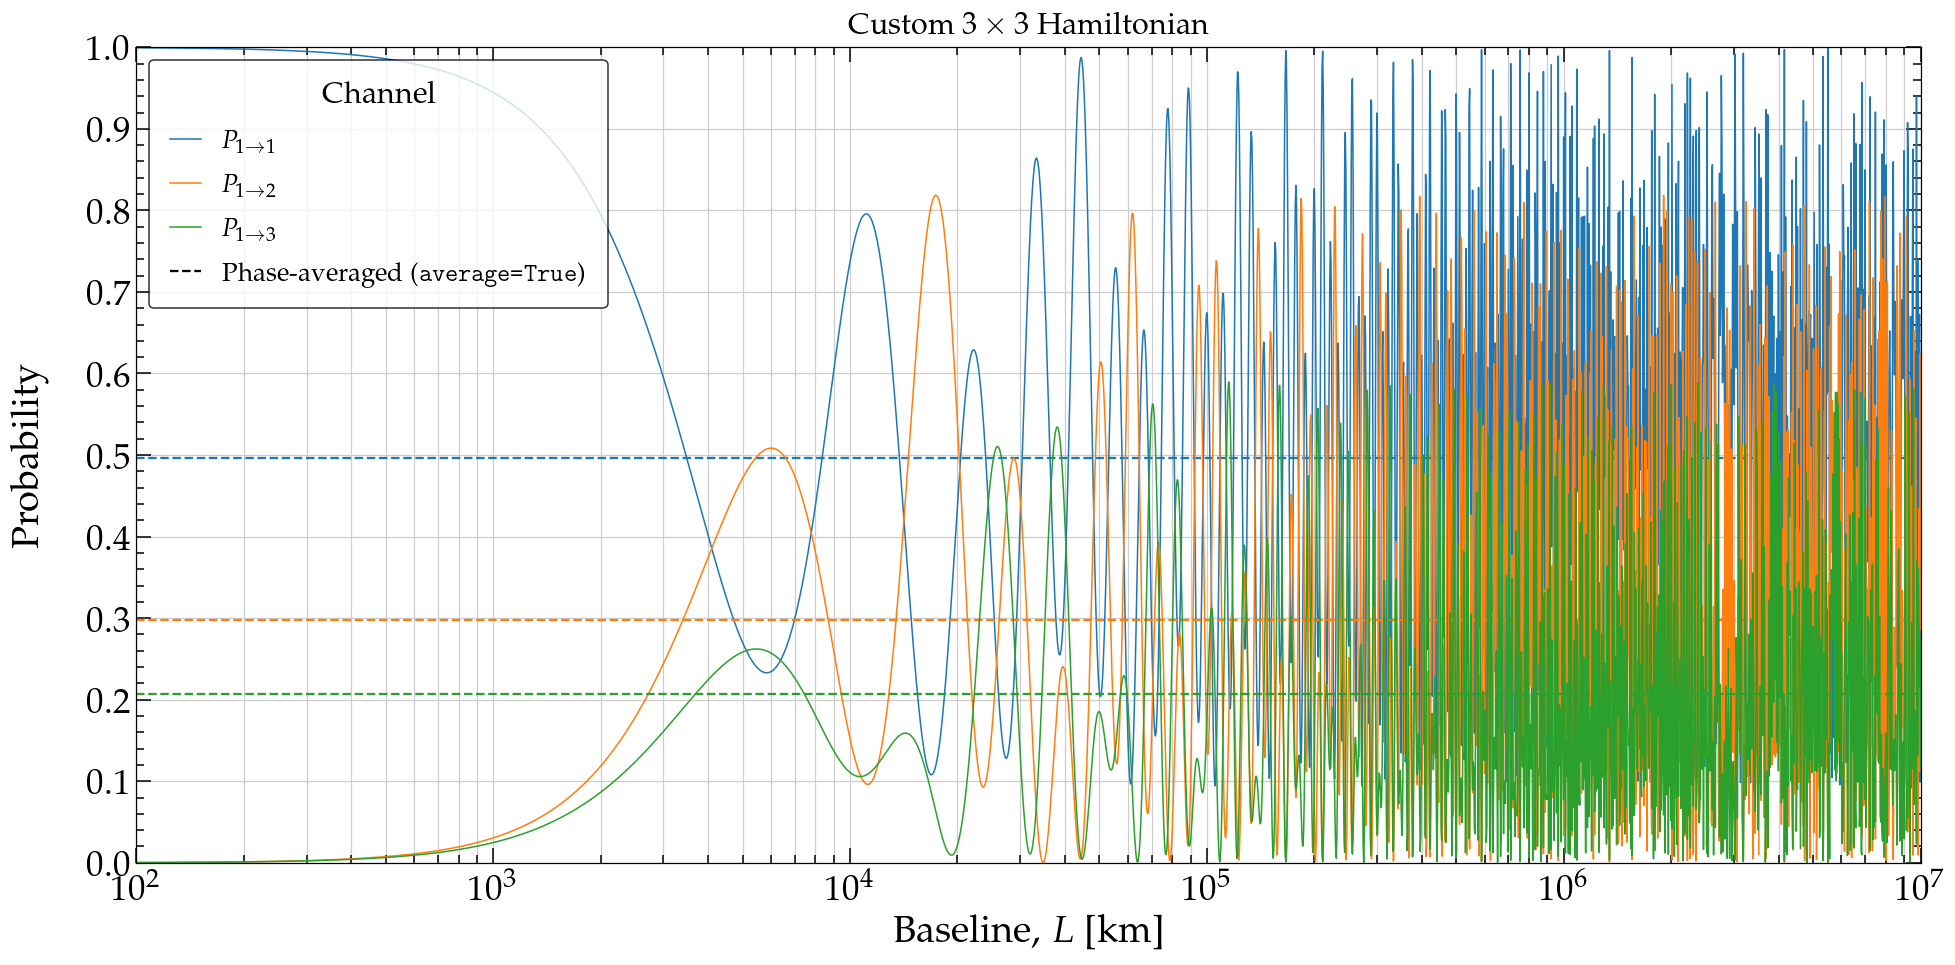

In [7]:
def custom_mixing_matrix(theta, phi, chi):
    '''An arbitrary 3x3 unitary, built as three rotations with one complex phase.'''
    c, s = np.cos(theta), np.sin(theta)
    R1 = np.array([[c, s, 0.0], [-s, c, 0.0], [0.0, 0.0, 1.0]], dtype=complex)
    c, s = np.cos(phi), np.sin(phi)
    R2 = np.array([[1.0, 0.0, 0.0], [0.0, c, s], [0.0, -s, c]], dtype=complex)
    c, s = np.cos(chi), np.sin(chi)
    R3 = np.array([[c, 0.0, s*np.exp(-1j*1.1)], [0.0, 1.0, 0.0],
                   [-s*np.exp(1j*1.1), 0.0, c]], dtype=complex)
    return R1 @ R3 @ R2


# A custom, energy-independent Hamiltonian: eigenvalues of our choosing in a
# mixing basis of our choosing, plus a small non-standard off-diagonal term.
U_custom = custom_mixing_matrix(0.6, 0.8, 0.25)
eigenvalues = np.array([0.0, 3.0e-14, 1.1e-13])       # [eV]
H_custom = U_custom @ np.diag(eigenvalues).astype(complex) @ U_custom.conj().T
H_custom = H_custom + 2.0e-15*np.array([[0.0, 0.0, 1.0],
                                        [0.0, 0.0, 0.0],
                                        [1.0, 0.0, 0.0]], dtype=complex)

print('Hermitian:', np.allclose(H_custom, H_custom.conj().T))

distances = np.logspace(np.log10(1.0e2), np.log10(1.0e7), 3000)*gd.UNIT_KM

# Oscillating: the primordial osc_prob, which takes any H(t).
P_osc = np.array([np.asarray(oscprob.osc_prob(lambda t: H_custom, 0.0, L))
                  for L in distances])

# Averaged: hand the same matrix to avgprob.
P_avg = avgprob.averaged_probabilities_constant_hamiltonian(H_custom)

print('averaged custom-Hamiltonian matrix:')
print(np.round(P_avg, 4))
print('symmetric:', np.allclose(P_avg, P_avg.T))

plot_oscillating_and_averaged(
    distances,
    [P_osc[:, 0, 0], P_osc[:, 0, 1], P_osc[:, 0, 2]],
    [P_avg[0, 0], P_avg[0, 1], P_avg[0, 2]],
    [r'$P_{1 \to 1}$', r'$P_{1 \to 2}$', r'$P_{1 \to 3}$'],
    r'Custom $3\times3$ Hamiltonian',
    'prob_custom_hamiltonian_averaged_vs_baseline.pdf',
    ylabel=r'Probability')

## When the average does not apply

The averaged expression is a limit, and Magνs checks whether the request is
actually in it.  At a terrestrial baseline the solar pair has accumulated a
fraction of a radian and has not decohered at all, so no averaged expression
describes the result — and asking for one warns instead of quietly answering.

In [8]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    P_here = oscprob.osc_prob_3nu_vacuum(1.0*gd.UNIT_GEV, 1000.0*gd.UNIT_KM,
                                         average=True, **osc)

for w in caught:
    if issubclass(w.category, oscprob.PhaseAveragingWarning):
        print('PhaseAveragingWarning:')
        print(' ', str(w.message)[:300], '...')

# The same check, done directly: which pairs are in neither limit?
eigenvalues = np.array([0.0, osc['D21'], osc['D31']])/(2.0*gd.UNIT_GEV)
for baseline_km in [1.0e3, 1.0e6, 1.0e8]:
    blocks, undecided = avgprob.coherence_report(eigenvalues, baseline_km*gd.UNIT_KM)
    print(f'L = {baseline_km:9.0e} km   blocks={blocks}   '
          f'pairs in neither limit: {[(i, j) for i, j, _ in undecided]}')

L =     1e+03 km   blocks=[[0, 1, 2]]   pairs in neither limit: [(0, 1), (1, 2)]
L =     1e+06 km   blocks=[[0], [1], [2]]   pairs in neither limit: []
L =     1e+08 km   blocks=[[0], [1], [2]]   pairs in neither limit: []


## Cost

The averaged probability is not just exact — it is far cheaper than the
propagation it replaces, because it never resolves the phase it is about to
discard.

In [9]:
import time

energy, L_far = 1.0*gd.UNIT_GEV, 1.0e8*gd.UNIT_KM

t0 = time.perf_counter()
for _ in range(100):
    oscprob.osc_prob_3nu_vacuum(energy, L_far, average=True, **osc)
t_avg = (time.perf_counter() - t0)/100

energies = 1.0/np.linspace(1.0/(10.0*gd.UNIT_GEV), 1.0/energy, 2001)
t0 = time.perf_counter()
P_num = np.asarray(oscprob.osc_prob_3nu_vacuum(energies, L_far, **osc)).mean(axis=0)
t_num = time.perf_counter() - t0

P_closed = np.asarray(oscprob.osc_prob_3nu_vacuum(energy, L_far, average=True, **osc))

print(f'closed form            : {t_avg*1e6:8.1f} us   (exact)')
print(f'averaging 2001 energies: {t_num:8.3f} s    (approximate)')
print(f'agreement              : {np.max(np.abs(P_num - P_closed)):.2e}')

closed form            :    159.8 us   (exact)
averaging 2001 energies:    0.644 s    (approximate)
agreement              : 1.32e-04


## Summary

* `average=True` works on every oscillation-probability function, for any
  number of flavors, and on any Hamiltonian — including one of your own.
* For a position-independent Hamiltonian it is the exact $L/E \to \infty$
  limit, in closed form, for the cost of one eigendecomposition.
* For vacuum it does not depend on energy or baseline at all: one matrix serves
  a whole flux calculation.
* Whether the limit *applies* is checked, not assumed.  A pair of eigenvalues
  that has neither decohered nor stayed coherent is reported rather than
  answered.
* Position-dependent profiles decohere in the eigenbasis at production and are
  carried along the levels of the instantaneous Hamiltonian, with exact
  level-crossing probabilities where the evolution stops being adiabatic; see
  the [documentation](https://mbustama.github.io/Magnus/averaged_probability.html).